In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [4]:
df = pd.read_csv('https://drive.google.com/uc?export=download&id=17fTFGD01VaAQ2H-rQDfH1NbkkBRs44AR')

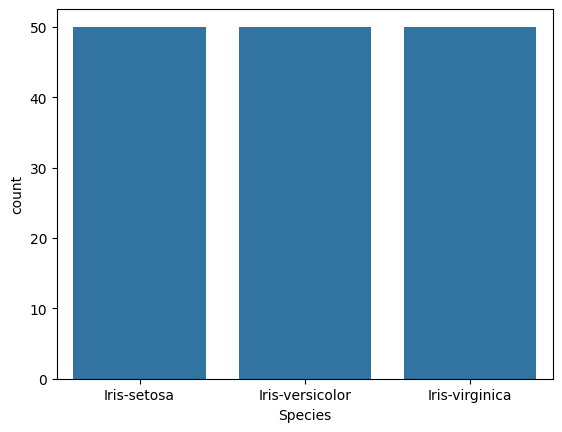

In [5]:
sns.countplot(x="Species", data=df)
plt.show()

In [6]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df["SpeciesEncoded"] = le.fit_transform(df["Species"])

In [9]:
# Fitur untuk clustering
X = df.drop(["Id", "Species", "SpeciesEncoded"], axis=1)

In [14]:
X[7:15]

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
7,5.0,3.4,1.5,0.2
8,4.4,2.9,1.4,0.2
9,4.9,3.1,1.5,0.1
10,5.4,3.7,1.5,0.2
11,4.8,3.4,1.6,0.2
12,4.8,3.0,1.4,0.1
13,4.3,3.0,1.1,0.1
14,5.8,4.0,1.2,0.2


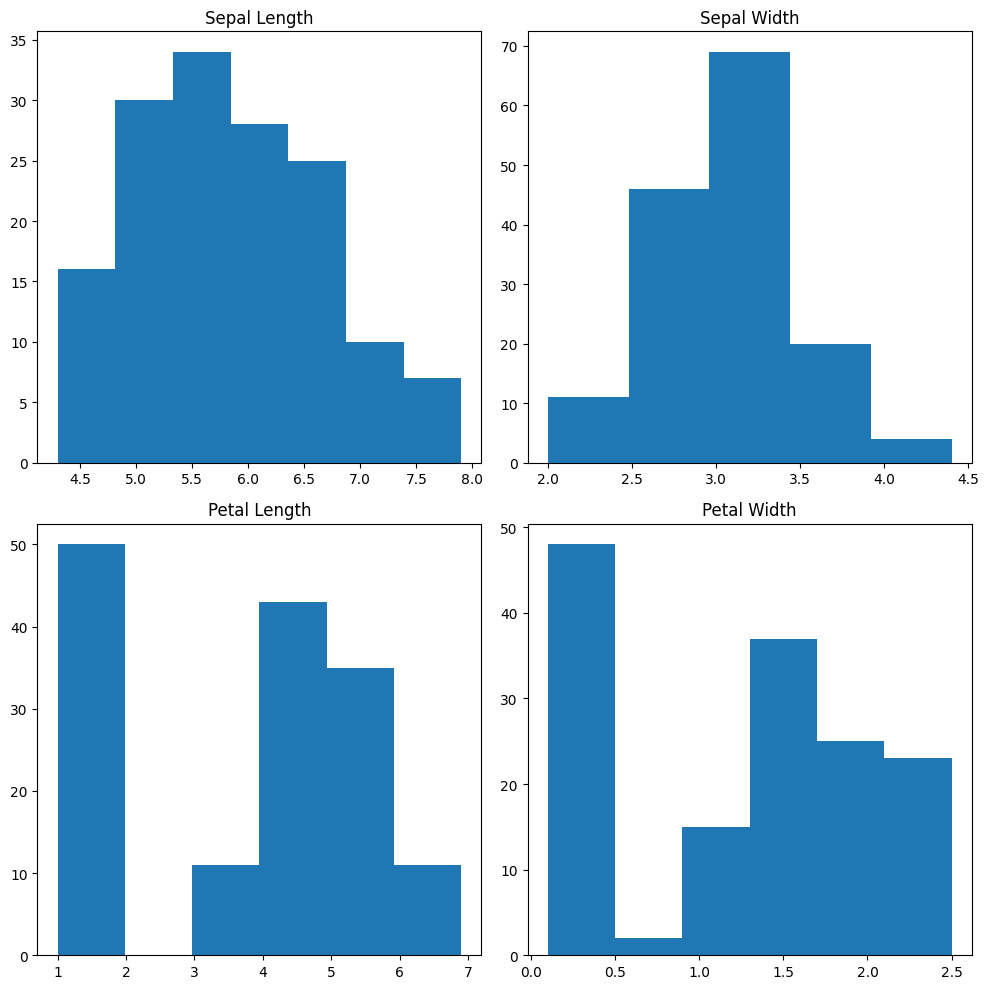

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(10, 10))

# Histogram 1: Sepal Length
axes[0, 0].set_title("Sepal Length")
axes[0, 0].hist(X['SepalLengthCm'], bins=7)

# Histogram 2: Sepal Width
axes[0, 1].set_title("Sepal Width")
axes[0, 1].hist(X['SepalWidthCm'], bins=5)

# Histogram 3: Petal Length
axes[1, 0].set_title("Petal Length")
axes[1, 0].hist(X['PetalLengthCm'], bins=6)

# Histogram 4: Petal Width
axes[1, 1].set_title("Petal Width")
axes[1, 1].hist(X['PetalWidthCm'], bins=6)

plt.tight_layout()
plt.show()

In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Re-initialize X from the original DataFrame 'df'
# This ensures X is a DataFrame with named columns for indexing before scaling
X = df[['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']]

# Now apply the scaling
X = scaler.fit_transform(X)
X[:5]

array([[-0.90068117,  1.03205722, -1.3412724 , -1.31297673],
       [-1.14301691, -0.1249576 , -1.3412724 , -1.31297673],
       [-1.38535265,  0.33784833, -1.39813811, -1.31297673],
       [-1.50652052,  0.10644536, -1.2844067 , -1.31297673],
       [-1.02184904,  1.26346019, -1.3412724 , -1.31297673]])

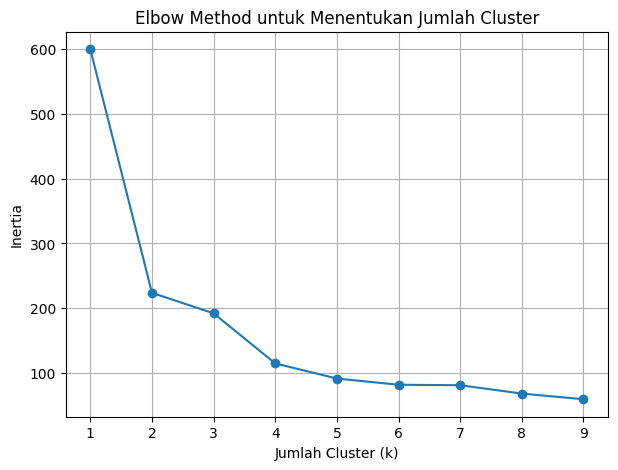

In [34]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia_list = []
K_range = range(1, 10)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init='auto')
    km.fit(X)
    inertia_list.append(km.inertia_)

plt.figure(figsize=(7,5))
plt.plot(K_range, inertia_list, marker='o')
plt.title("Elbow Method untuk Menentukan Jumlah Cluster")
plt.xlabel("Jumlah Cluster (k)")
plt.ylabel("Inertia")
plt.grid(True)
plt.show()

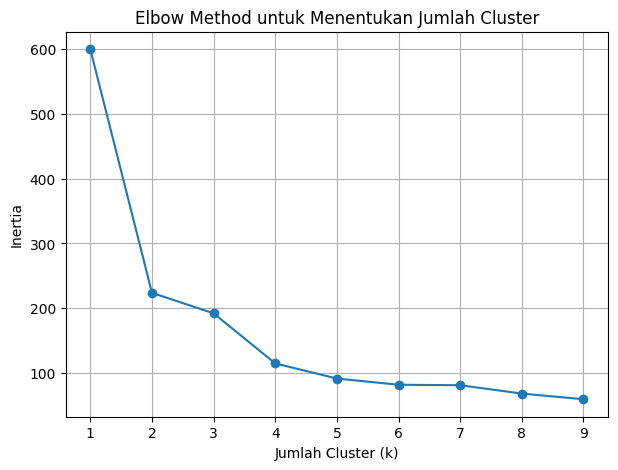

In [35]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

inertia_list = []
K_range = range(1, 10)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init='auto')
    km.fit(X_scaled)
    inertia_list.append(km.inertia_)

plt.figure(figsize=(7,5))
plt.plot(K_range, inertia_list, marker='o')
plt.title("Elbow Method untuk Menentukan Jumlah Cluster")
plt.xlabel("Jumlah Cluster (k)")
plt.ylabel("Inertia")
plt.grid(True)
plt.show()


In [27]:
from sklearn.cluster import KMeans
kmeans = KMeans(
    n_clusters=3,       # Karena dataset Iris ada 3 spesies
    init= "k-means++",
    random_state=42
)

In [28]:
# 1. Latih model (menentukan centroid + proses clustering)
kmeans.fit(X)


KMeans(n_clusters=3, random_state=42)

In [30]:

# 2. Prediksi cluster untuk data X
labels = kmeans.predict(X)

In [31]:
# 3. Masukkan ke DataFrame
df["Cluster"] = labels

In [32]:
# df["Cluster"]- kmeans.fit_predict(X)

print("Cluster ditemukan:", df["Cluster"].unique())

Cluster ditemukan: [1 2 0]


In [36]:
from sklearn.metrics import silhouette_score

sill_score = silhouette_score(X, df["Cluster"])
print("\n=====SILHOULETTE SCORE =====")
print("Silhouette Score:", sill_score)


=====SILHOULETTE SCORE =====
Silhouette Score: 0.4787241921049546


In [37]:
from sklearn.metrics import confusion_matrix, classification_report
print("\n=====CONFUSION MATRIX=====")
cm = confusion_matrix(df["SpeciesEncoded"], df["Cluster"])
print(cm)


=====CONFUSION MATRIX=====
[[ 0 32 18]
 [46  0  4]
 [50  0  0]]


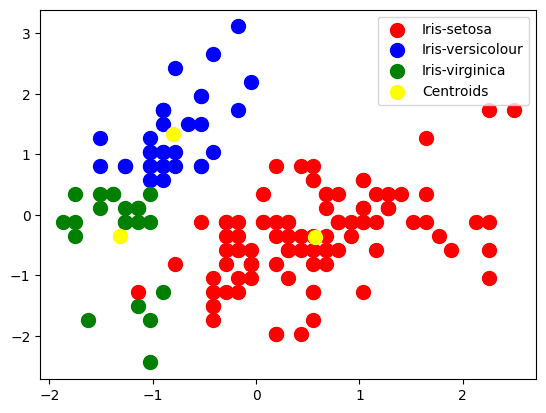

In [40]:
# Visualising the clusters
plt.scatter(X[df["Cluster"] == 0, 0], X[df["Cluster"] == 0, 1], s=100, c='red', label='Iris-setosa')
plt.scatter(X[df["Cluster"] == 1, 0], X[df["Cluster"] == 1, 1], s=100, c='blue', label='Iris-versicolour')
plt.scatter(X[df["Cluster"] == 2, 0], X[df["Cluster"] == 2, 1], s=100, c='green', label='Iris-virginica')

# Plotting the centroids of the clusters
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=100, c='yellow', label='Centroids')

plt.legend()
plt.show()